# Lesson 4: Pixel Measurement Model

**Description:** 

**Requirement(s):** None

**Author:** Matthew O'Toole

---

#### The Image Formation Model

The paper titled [*Noise-Optimal Capture for High Dynamic Range Photography*](https://people.csail.mit.edu/hasinoff/pubs/hasinoff-hdrnoise-2010.pdf) by Hasinoff et al. provides a solid overview of the pixel measurement model; we adopt their notation and summarize their discussion here. The model converts radiant power $\Phi$ (measured in terms of units of electrons per second) into measured pixel values (given in digital numbers, or DN):
$$I = \min \{ \Phi t / g + I_0 + n, I_{\max} \}$$
Here, $t$ (seconds) represents the exposure time, $g$ (electrons per DN) represents the sensor gain, $I_0$ (DN) represents the pixel value corresponding to the black level, $n$ represents noise, and $I_{\max}$ is the saturation level.  Note that gain is inversely proportional to the camera's ISO $G$ (i.e., $g \propto 1/G$).

Provided that the signal is below the saturation level, the variance for the noise $n$ is the following:
$$\text{Var}(n) = \Phi t / g^2 + \sigma^2_{\text{read}} / g^2 + \sigma^2_{\text{ADC}}$$
where $\sigma_{\text{read}}$ is the read noise pre-amplification (from the pixel), and $\sigma_{\text{ADC}}$ is the read noise due to downstream electronics (from the analog-to-digital converter).

$$\text{SNR}(\Phi)^2 = \frac{E[I]^2}{\text{Var}(n)} \approx \frac{\Phi^2 t^2 \cdot (I < I_{\max})}{\Phi t + \sigma^2_{\text{read}} + \sigma^2_{\text{ADC}}g^2}$$

A few observations from this image formation model:
* When the number of detected photoelectrons $\Phi t$ is small, the dominant source of noise is due to read noise, which is Gaussian distributed.  We refer to the system as being read noise limited.
* As the signal increases, the dominant source of noise is due to the signal itself, which is poisson distributed. We refer to the system as being shot noise limited.
* When the signal is low, it is better to decrease the value of $g$ (i.e., use a larger ISO) to amplify the signal.  This reduces the influence of $\sigma_{\text{ADC}}$.

Limitations:
* Ignores dark current.
* Ignores fixed pattern noise.
* Idealized image formation model.
* Color filter array.

In [664]:
import bpy
import bmesh
import numpy as np
import matplotlib.pyplot as plt
import import_ipynb

from L001_hello_world import render, clear_scene

# Clear scene
if __name__ == '__main__':
    clear_scene()

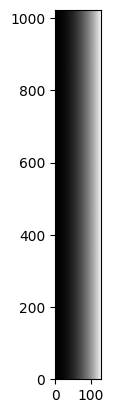

In [665]:
if __name__ == '__main__':
    # Set render engine and resolution for ray tracing
    bpy.context.scene.render.engine = 'CYCLES'
    bpy.context.scene.render.resolution_x = 128
    bpy.context.scene.render.resolution_y = 1024
    bpy.context.scene.render.image_settings.file_format = 'HDR'

    # Do not reduce number of samples per pixel based on render noise
    bpy.context.scene.cycles.use_adaptive_sampling = False 

    # Set number of samples to render at each pixel
    bpy.context.scene.cycles.samples = 10

    # Do not denoise the rendered image
    bpy.context.scene.cycles.use_denoising = False

    # Set film filter to box
    bpy.context.scene.cycles.pixel_filter_type = 'BOX'

    # Change camera exposure (in EV steps, default is 0.0)
    #bpy.context.scene.cycles.film_exposure = 0.01


    # Create camera
    bpy.ops.object.camera_add(rotation=(np.pi/2, 0, 0))
    cam = bpy.context.active_object
    bpy.context.scene.camera = cam

    # Set camera to orthographic
    cam.data.type = 'ORTHO'
    cam.data.ortho_scale = 2


    # Add emissive material
    emissive_material = bpy.data.materials.new(name='Emissive Material')
    emissive_material.use_nodes = True

    nodes = emissive_material.node_tree.nodes
    bsdf = nodes['Principled BSDF']

    # Add plane to scene
    bpy.ops.mesh.primitive_plane_add(location=(0, 10, 0), 
                                     rotation=(np.pi/2, 0, 0))
    plane = bpy.context.active_object
    plane.scale = (128/1024, 1, 1)
    plane.data.materials.append(emissive_material)

    gradient = nodes.new(type='ShaderNodeTexGradient')
    gradient.location.x = bsdf.location.x - 200
    gradient.location.y = bsdf.location.y
    gradient.gradient_type = 'QUADRATIC'


    links = emissive_material.node_tree.links
    links.new(gradient.outputs['Color'], bsdf.inputs['Emission Strength'])
    
    

    # Render scene
    bpy.context.scene.cycles.film_exposure = 1
    plt.imshow(render(), origin='lower')

In [666]:
# Canon EOS 1D Mark III
def add_sensor_noise(intensity,
              iso        = 100,
              bit_depth  = 14,
              unity_iso  = 436.8,
              read_noise = 4.7,
              adc_noise  = 5.4,
              offset     = 1024,
              raw        = False):

    I_max = 2**bit_depth - 1
    gain = unity_iso / iso
    full_well_capacity = (I_max - offset) * gain * iso / 100
    
    electrons = np.random.poisson(intensity * full_well_capacity)
    electrons = electrons + np.random.normal(scale=read_noise, 
                                             size=electrons.shape)

    DN = electrons / gain
    DN = DN + np.random.normal(scale=adc_noise, size=DN.shape)
    DN = DN + offset
    DN = np.clip(DN, 0, I_max)

    if raw:
        return DN.astype(np.uint16)

    return (DN - offset) / (I_max - offset)

In [667]:
# Canon EOS 1D Mark III
def get_sensor_noise_statistics(intensity,
                                iso        = 100,
                                bit_depth  = 14,
                                unity_iso  = 436.8,
                                read_noise = 4.7,
                                adc_noise  = 5.4,
                                offset     = 1024,
                                raw        = False):

    I_max = 2**bit_depth - 1
    gain = unity_iso / iso
    full_well_capacity = (I_max - offset) * gain * iso / 100
    
    electrons_mean = intensity * full_well_capacity
    electrons_var = electrons_mean + read_noise**2

    DN_mean = electrons_mean / gain + offset
    DN_var = electrons_var / gain**2 + adc_noise**2
    DN_var[DN_mean >= I_max] = np.inf

    if raw:
        return DN_mean, DN_var
    
    DN_mean = (DN_mean - offset) / (I_max - offset)
    DN_var  = DN_var / (I_max - offset)**2

    return DN_mean, DN_var

In [668]:
bpy.context.scene.cycles.film_exposure = 1
intensity = render()

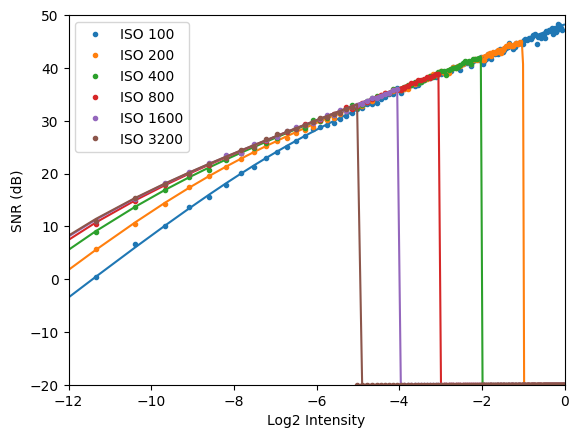

In [669]:
for stop in range(6):
    iso = 100 * 2**stop

    photo = add_sensor_noise(intensity, iso=iso)

    I_mean, I_var = get_sensor_noise_statistics(intensity, iso=iso)

    signal = np.mean(photo[:,:,0], axis=0)
    var = np.var(photo[:,:,0], axis=0)
    snr = signal / np.clip(np.sqrt(var), 1e-6, None)
    snr = np.clip(snr * (signal < 0.97), 1e-1, None)

    snr2 =  I_mean / np.clip(np.sqrt(I_var), 1e-9, None)
    snr2[(iso / 100) * intensity >= 1] = 1e-1
    snr2 = np.mean(snr2[:,:,0], axis=0)

    plt.plot(np.log2(np.mean(intensity[:,:,0], axis=0)), 
             20 * np.log10(snr), '.', label='ISO %d' % iso, 
             color='C%d' % stop)
    plt.plot(np.log2(np.mean(intensity[:,:,0], axis=0)), 
             20 * np.log10(snr2), 
             color='C%d' % stop)

plt.legend()
plt.xlim(-12, 0)
plt.ylim(-20, 50)
plt.xlabel('Log2 Intensity')
plt.ylabel('SNR (dB)');

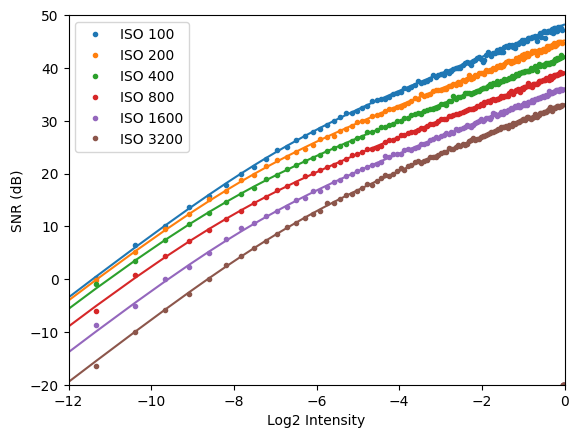

In [670]:
for stop in range(6):
    iso = 100 * 2**stop
    
    photo = add_sensor_noise(intensity / 2**stop, iso=iso)
    
    I_mean, I_var = get_sensor_noise_statistics(intensity / 2**stop, iso=iso)

    signal = np.mean(photo[:,:,0], axis=0)
    var = np.var(photo[:,:,0], axis=0)
    snr = signal / np.clip(np.sqrt(var), 1e-6, None)
    snr = np.clip(snr * (signal < 0.97), 1e-1, None)

    snr2 = I_mean / np.clip(np.sqrt(I_var), 1e-6, None)
    snr2 = np.mean(snr2[:,:,0], axis=0)

    plt.plot(np.log2(np.mean(intensity[:,:,0], axis=0)), 
             20 * np.log10(snr), '.', label='ISO %d' % iso,
             color='C%d' % stop)
    plt.plot(np.log2(np.mean(intensity[:,:,0], axis=0)), 
             20 * np.log10(snr2),
             color='C%d' % stop)

plt.legend()
plt.xlim(-12, 0)
plt.ylim(-20, 50)
plt.xlabel('Log2 Intensity')
plt.ylabel('SNR (dB)');

#### Additional Resources

DxOMark Derived Sensor Characteristics:
https://www.photonstophotos.net/Charts/Sensor_Characteristics.htm

Photon Transfer Curve:
https://www.photonstophotos.net/Charts/PTC.htm

The book [*Transfer Curve*](https://www.spiedigitallibrary.org/ebooks/PM/Photon-Transfer/eISBN-9780819478382/10.1117/3.725073) by James R. Janesick:

picture.iczhiku.com/resource/eetop/shITqHhziPtOLvcx.pdf

https://people.csail.mit.edu/hasinoff/pubs/hasinoff-hdrnoise-2010.pdf